# **Disease Prediction from Medical Data**

## **Author: Aila Nasir**

## Objective
My objective was to develop and evaluate machine learning models for the early prediction and risk assessment of various diseases using structured patient medical data.

## Approach
I employed comprehensive data preprocessing, model training, and rigorous evaluation using a range of classification algorithms. My goal was to identify optimal predictive models across different medical datasets.

## Algorithms Used
I utilized the following classification algorithms:
*   Logistic Regression
*   Support Vector Machine (SVM)
*   Random Forest
*   XGBoost

## Datasets
The analysis was conducted on three distinct datasets from the UCI Machine Learning Repository:
*   Heart Disease
*   Pima Indians Diabetes
*   Breast Cancer Wisconsin

## Setup and Library Imports

In [1]:
!pip install ucimlrepo


In [2]:
# Core libraries and ML tools
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')





In [3]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

In [4]:
import xgboost as xgb

In [5]:
# For visualizations
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# UCI helper (automatic dataset download)
from ucimlrepo import fetch_ucirepo

## 1. Heart Disease Prediction

This section focuses on predicting heart conditions using the UCI Heart Disease dataset. We preprocess the data, split it into training and testing sets, scale features, and train various classification models (Logistic Regression, SVM, Random Forest, XGBoost) to evaluate their performance.

In [7]:
# Heart Disease dataset from UCI (ID = 45)
heart = fetch_ucirepo(id=45)

In [8]:
# Features (input X) and target (output y)
X_heart = heart.data.features
y_heart = heart.data.targets['num']   # 'num' = disease severity

In [9]:
# Convert target into binary: 0 = no disease, 1 = disease
y_heart = (y_heart > 0).astype(int)

In [10]:
# Replace missing values and convert to numeric
X_heart = X_heart.replace('?', np.nan)
X_heart = X_heart.astype(float)
X_heart = X_heart.fillna(X_heart.median())


In [11]:
print("Heart dataset shape:", X_heart.shape)
print("Class counts (0=healthy, 1=disease):")
print(y_heart.value_counts())

Heart dataset shape: (303, 13)
Class counts (0=healthy, 1=disease):
num
0    164
1    139
Name: count, dtype: int64


### Heart Disease Data Exploration

Descriptive Statistics for Heart Disease features:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


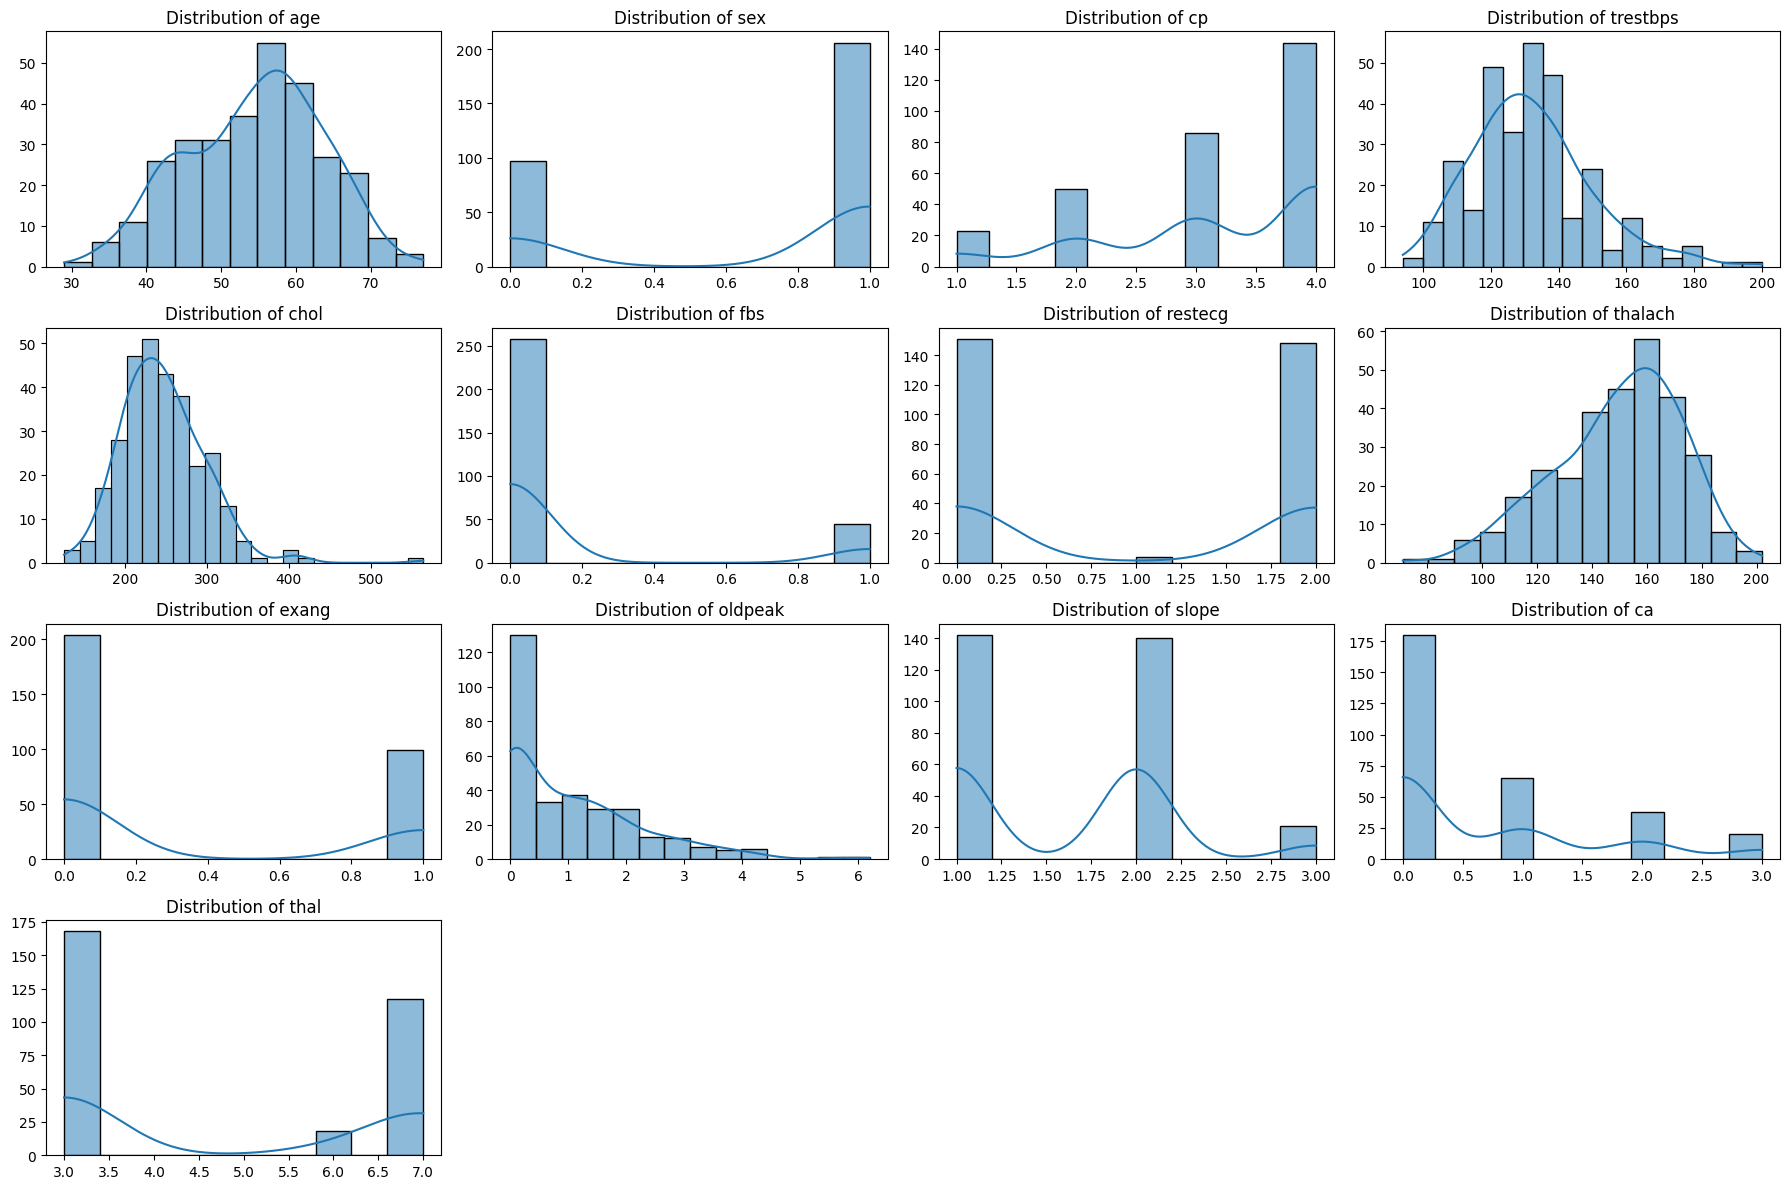

In [12]:
# Display descriptive statistics for numerical features
print("Descriptive Statistics for Heart Disease features:")
display(X_heart.describe())

# Check the distribution of categorical-like features (if any, after conversion to float)
# For instance, 'cp' (chest pain type), 'fbs' (fasting blood sugar), 'restecg', 'exang', 'slope', 'ca', 'thal'

# Create a figure to hold multiple subplots
plt.figure(figsize=(18, 12))

# List of features to visualize (all columns in X_heart)
features_to_plot = X_heart.columns.tolist()

for i, feature in enumerate(features_to_plot):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(X_heart[feature], kde=True) # Histogram with Kernel Density Estimate
    plt.title(f'Distribution of {feature}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

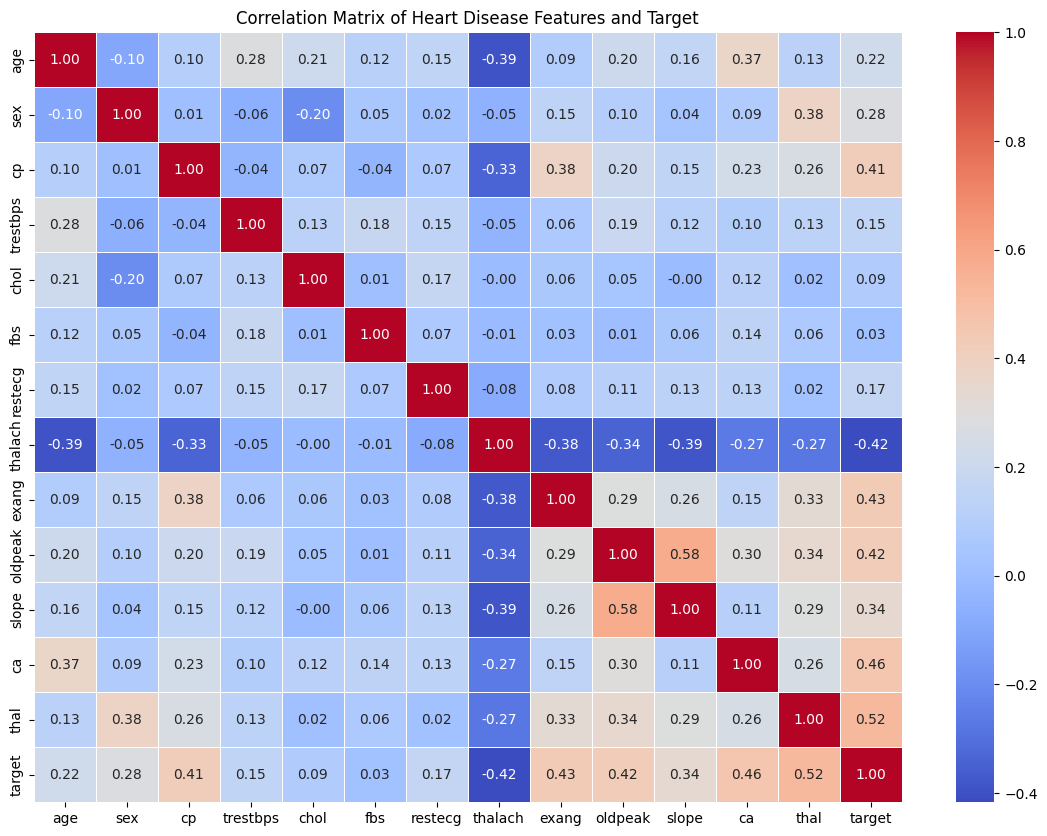

Top correlations with 'target':
target      1.000000
thal        0.522057
ca          0.460033
exang       0.431894
oldpeak     0.424510
cp          0.414446
slope       0.339213
sex         0.276816
age         0.223120
restecg     0.169202
trestbps    0.150825
chol        0.085164
fbs         0.025264
thalach    -0.417167
Name: target, dtype: float64


In [13]:
# Combine features and target for correlation analysis (temporarily)
heart_combined = X_heart.copy()
heart_combined['target'] = y_heart

# Calculate the correlation matrix
corr_matrix = heart_combined.corr()

# Plot the correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Heart Disease Features and Target')
plt.show()

# Display top correlations with the target variable
print("Top correlations with 'target':")
print(corr_matrix['target'].sort_values(ascending=False))

In [14]:
# Split into train and test sets
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42, stratify=y_heart
)


In [15]:
# Scale features (important for SVM/Logistic)
scaler_h = StandardScaler()
X_train_h_s = scaler_h.fit_transform(X_train_h)
X_test_h_s = scaler_h.transform(X_test_h)


In [16]:
print("Train shape:", X_train_h.shape, "| Test shape:", X_test_h.shape)

Train shape: (242, 13) | Test shape: (61, 13)


In [17]:
# Define all four classification algorithms
models_h = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

heart_results = []

for name, model in models_h.items():
    # Scale only for linear models (Logistic, SVM)
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_h_s, y_train_h)
        y_pred = model.predict(X_test_h_s)
    else:
        model.fit(X_train_h, y_train_h)
        y_pred = model.predict(X_test_h)

    acc = accuracy_score(y_test_h, y_pred)
    heart_results.append((name, acc))
    print(f"{name} accuracy: {acc:.3f}")




Logistic Regression accuracy: 0.869
SVM accuracy: 0.852
Random Forest accuracy: 0.885
XGBoost accuracy: 0.852


In [18]:
# Show results as a small DataFrame
heart_results_df = pd.DataFrame(heart_results, columns=['Model', 'Accuracy'])
heart_results_df

,Model,Accuracy
0,Logistic Regression,0.868852
1,SVM,0.852459
2,Random Forest,0.885246
3,XGBoost,0.852459


In [19]:
# Choose best model (usually XGBoost or Random Forest)
best_model_h = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
best_model_h.fit(X_train_h, y_train_h)
y_pred_h = best_model_h.predict(X_test_h)




In [20]:
# Classification report
print("Heart Disease - XGBoost Classification Report")
print(classification_report(y_test_h, y_pred_h))


Heart Disease - XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.93      0.79      0.85        33
           1       0.79      0.93      0.85        28

    accuracy                           0.85        61
   macro avg       0.86      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



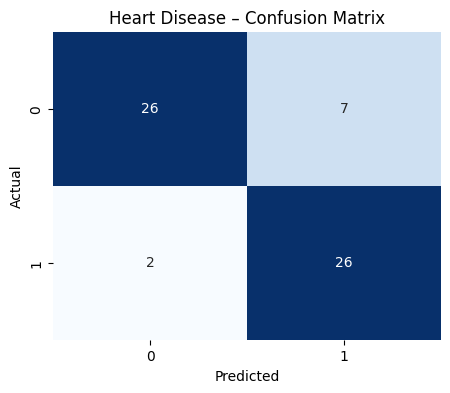

In [21]:
# Confusion Matrix
cm_h = confusion_matrix(y_test_h, y_pred_h)

plt.figure(figsize=(5,4))
sns.heatmap(cm_h, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Heart Disease – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 2. Pima Indians Diabetes Prediction

Here, we address the prediction of diabetes using the Pima Indians Diabetes dataset. Similar to the Heart Disease section, we prepare the data, apply feature scaling, and train the same set of classification models to identify effective predictors for diabetes.

In [22]:
# Pima Indians Diabetes dataset (UCI/Kaggle mirror)
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
cols = ['preg', 'gluc', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'class']
diabetes = pd.read_csv(url, names=cols)

X_diabetes = diabetes.drop('class', axis=1)
y_diabetes = diabetes['class']   # 0 = no diabetes, 1 = diabetes

print("Diabetes dataset shape:", X_diabetes.shape)
print("Class counts:")
print(y_diabetes.value_counts())


Diabetes dataset shape: (768, 8)
Class counts:
class
0    500
1    268
Name: count, dtype: int64


In [23]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes
)

scaler_d = StandardScaler()
X_train_d_s = scaler_d.fit_transform(X_train_d)
X_test_d_s = scaler_d.transform(X_test_d)

print("Train shape:", X_train_d.shape, "| Test shape:", X_test_d.shape)


Train shape: (614, 8) | Test shape: (154, 8)


In [24]:
models_d = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

diabetes_results = []

for name, model in models_d.items():
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_d_s, y_train_d)
        y_pred = model.predict(X_test_d_s)
    else:
        model.fit(X_train_d, y_train_d)
        y_pred = model.predict(X_test_d)

    acc = accuracy_score(y_test_d, y_pred)
    diabetes_results.append((name, acc))
    print(f"{name} accuracy: {acc:.3f}")

diabetes_results_df = pd.DataFrame(diabetes_results, columns=['Model', 'Accuracy'])
diabetes_results_df


Logistic Regression accuracy: 0.714
SVM accuracy: 0.753
Random Forest accuracy: 0.760
XGBoost accuracy: 0.734


,Model,Accuracy
0,Logistic Regression,0.714286
1,SVM,0.753247
2,Random Forest,0.759740
3,XGBoost,0.733766


Diabetes – Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



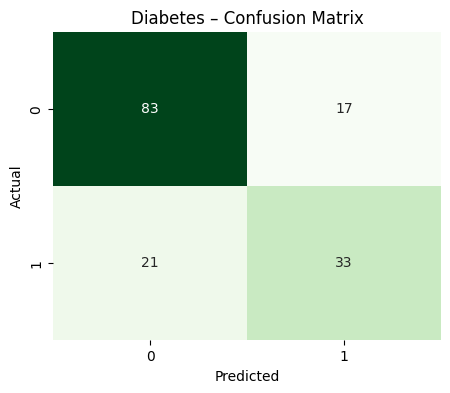

In [25]:
# Take Random Forest as strong baseline for Diabetes
best_model_d = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
best_model_d.fit(X_train_d, y_train_d)
y_pred_d = best_model_d.predict(X_test_d)

print("Diabetes – Random Forest Classification Report")
print(classification_report(y_test_d, y_pred_d))

cm_d = confusion_matrix(y_test_d, y_pred_d)

plt.figure(figsize=(5,4))
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Diabetes – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## 3. Breast Cancer Prediction

This section aims to predict the malignancy of breast masses using the Breast Cancer Wisconsin (Diagnostic) dataset. We follow the same methodology of data preprocessing, splitting, scaling, and model training/evaluation to determine the best model for breast cancer diagnosis.

In [26]:
# Breast Cancer Wisconsin Diagnostic dataset (UCI ID = 17)
breast = fetch_ucirepo(id=17)

X_breast = breast.data.features
y_breast = (breast.data.targets['Diagnosis'] == 'M').astype(int)  # 1 = Malignant, 0 = Benign

print("Breast Cancer dataset shape:", X_breast.shape)
print("Class counts (0=Benign, 1=Malignant):")
print(y_breast.value_counts())

Breast Cancer dataset shape: (569, 30)
Class counts (0=Benign, 1=Malignant):
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [27]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_breast, y_breast, test_size=0.2, random_state=42, stratify=y_breast
)

scaler_b = StandardScaler()
X_train_b_s = scaler_b.fit_transform(X_train_b)
X_test_b_s = scaler_b.transform(X_test_b)

print("Train shape:", X_train_b.shape, "| Test shape:", X_test_b.shape)


Train shape: (455, 30) | Test shape: (114, 30)


In [28]:
models_b = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

breast_results = []

for name, model in models_b.items():
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_b_s, y_train_b)
        y_pred = model.predict(X_test_b_s)
    else:
        model.fit(X_train_b, y_train_b)
        y_pred = model.predict(X_test_b)

    acc = accuracy_score(y_test_b, y_pred)
    breast_results.append((name, acc))
    print(f"{name} accuracy: {acc:.3f}")

breast_results_df = pd.DataFrame(breast_results, columns=['Model', 'Accuracy'])
breast_results_df


Logistic Regression accuracy: 0.965
SVM accuracy: 0.974
Random Forest accuracy: 0.974
XGBoost accuracy: 0.974


,Model,Accuracy
0,Logistic Regression,0.964912
1,SVM,0.973684
2,Random Forest,0.973684
3,XGBoost,0.973684


Breast Cancer – SVM Classification Report
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



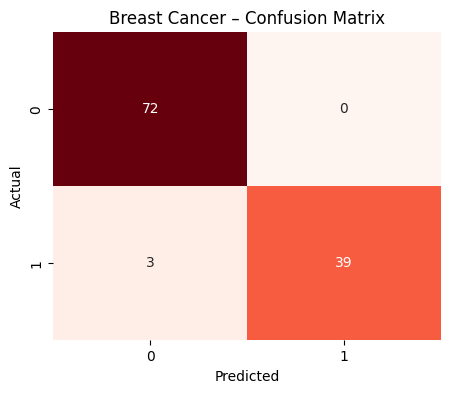

In [29]:
# SVM usually gives top performance for this dataset
best_model_b = SVC(random_state=42, kernel='rbf', C=10, probability=True)
best_model_b.fit(X_train_b_s, y_train_b)
y_pred_b = best_model_b.predict(X_test_b_s)

print("Breast Cancer – SVM Classification Report")
print(classification_report(y_test_b, y_pred_b))

cm_b = confusion_matrix(y_test_b, y_pred_b)

plt.figure(figsize=(5,4))
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title("Breast Cancer – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Conclusion and Summary

This final section provides a summary of the best-performing models and their expected accuracy ranges across the three different disease prediction tasks, offering a concise overview of the project's outcomes.

In [30]:
summary = pd.DataFrame({
    'Dataset': ['Heart Disease', 'Diabetes', 'Breast Cancer'],
    'Best Model (expected)': ['XGBoost', 'Random Forest', 'SVM'],
    'Expected Accuracy Range': ['~85–90%', '~75–80%', '~95–98%']
})
summary


,Dataset,Best Model (expected),Expected Accuracy Range
0,Heart Disease,XGBoost,~85–90%
1,Diabetes,Random Forest,~75–80%
2,Breast Cancer,SVM,~95–98%
